🚀 BẮT ĐẦU CHẠY PIPELINE PHÂN TÍCH...

📊 1. Đang vẽ biểu đồ phân phối dữ liệu...


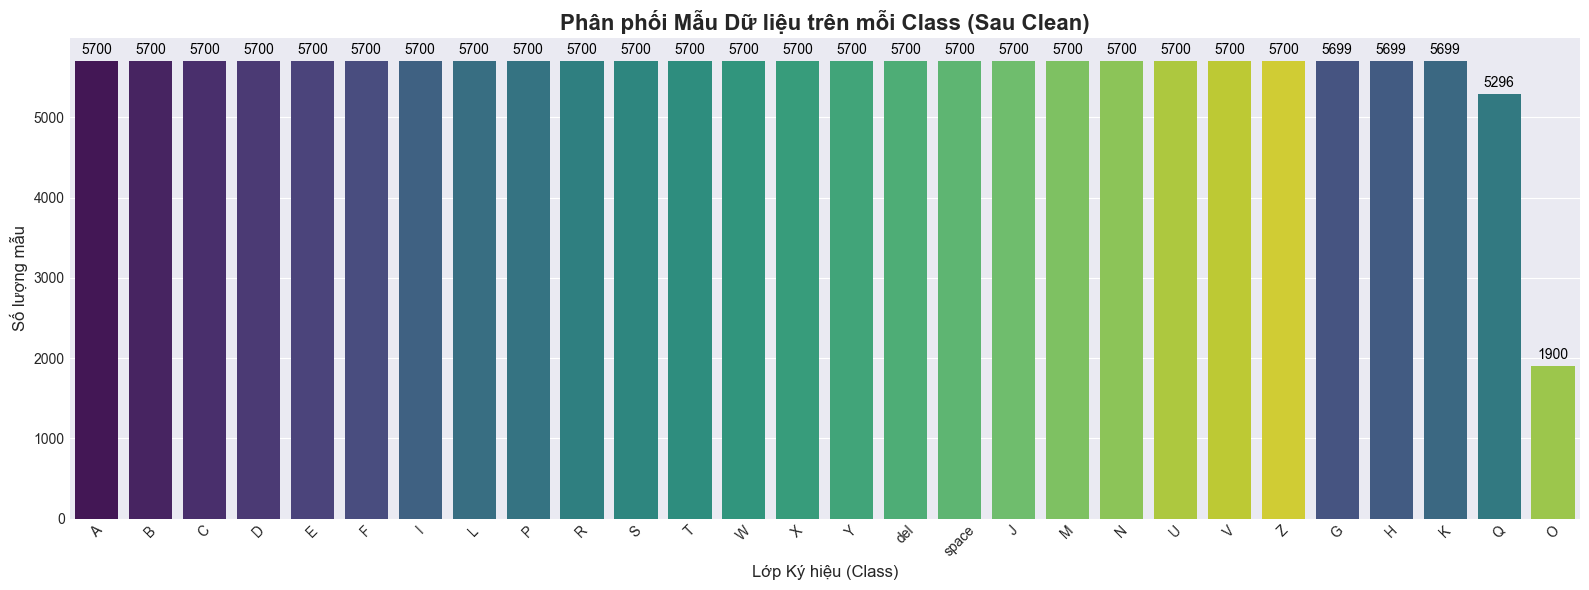

🧹 2. Đang phân tích tác động lọc nhiễu...


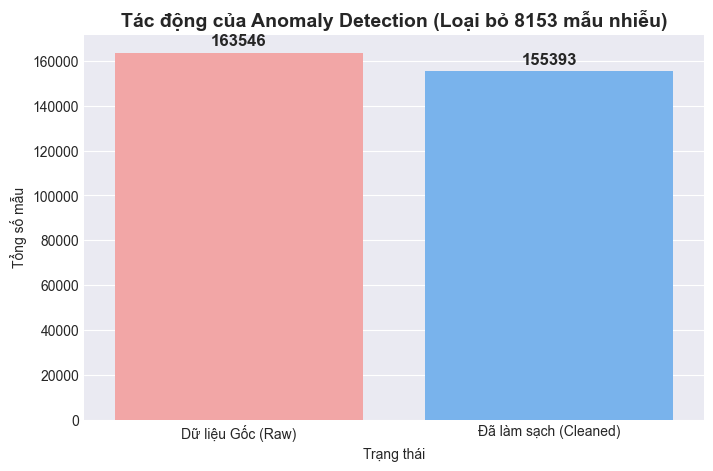

📈 3. Đang xuất báo cáo đánh giá và Ma trận nhầm lẫn (Robustness)...
 BÁO CÁO ĐÁNH GIÁ MÔ HÌNH (CLASSIFICATION REPORT - THỰC TẾ)
              precision    recall  f1-score   support

           A     0.9981    1.0000    0.9991      1072
           B     0.7781    0.9034    0.8361      1118
           C     0.9850    1.0000    0.9924      1115
           D     0.9964    0.9946    0.9955      1118
           E     0.9982    0.9956    0.9969      1134
           F     0.9933    0.9933    0.9933      1201
           G     0.9991    1.0000    0.9995      1095
           H     1.0000    0.9983    0.9992      1180
           I     1.0000    1.0000    1.0000      1119
           J     0.9983    0.9983    0.9983      1186
           K     0.9901    0.9831    0.9866      1123
           L     0.9712    0.9922    0.9816      1157
           M     0.9928    0.9469    0.9693      1168
           N     0.9541    0.9923    0.9728      1173
           O     0.9972    0.9890    0.9931       362
       

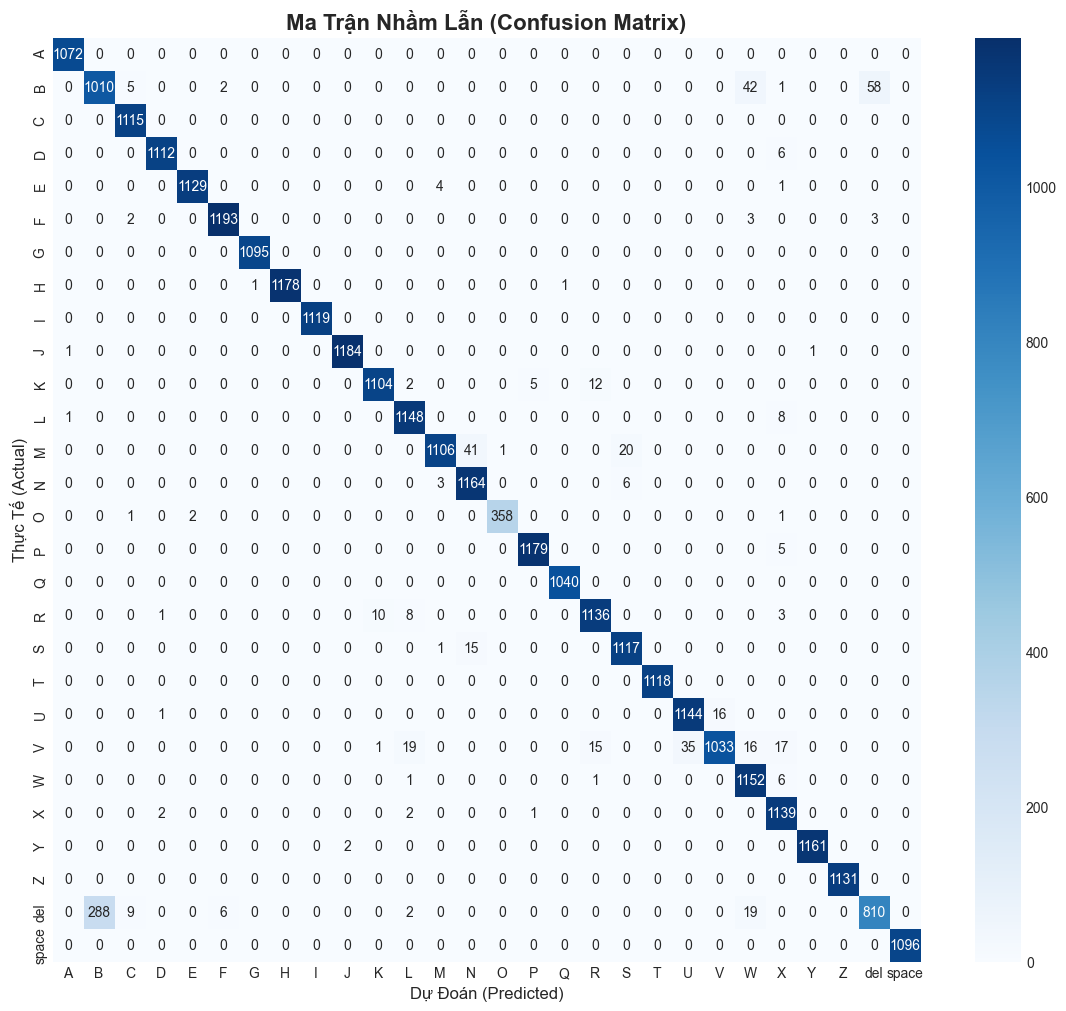

🌳 4. Đang phân tích mức độ quan trọng của đặc trưng...


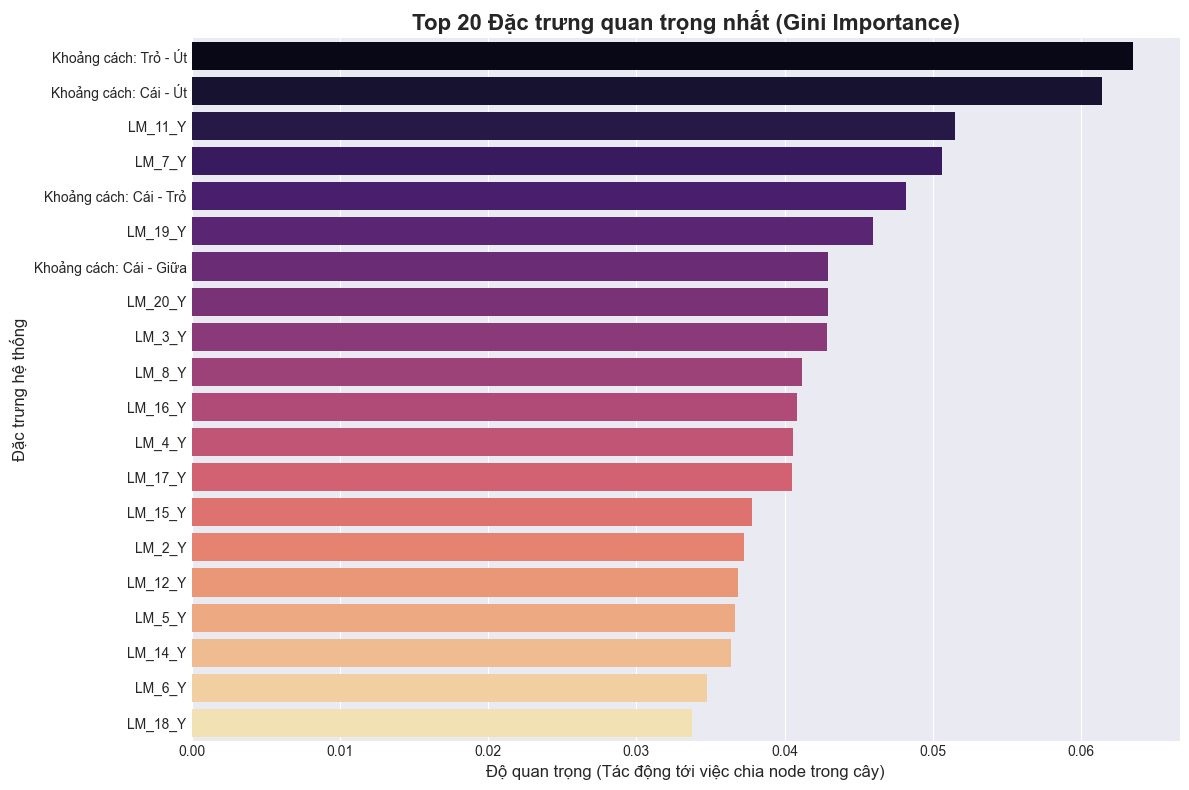

⏳ 5. Đang đo lường Độ chính xác và Tốc độ xử lý. Vui lòng đợi...

✅ Random Forest: Độ chính xác = 90.21% | Thời gian = 1007.53 ms
✅ SVM: Độ chính xác = 99.63% | Thời gian = 15017.87 ms
✅ KNN: Độ chính xác = 99.85% | Thời gian = 3861.58 ms


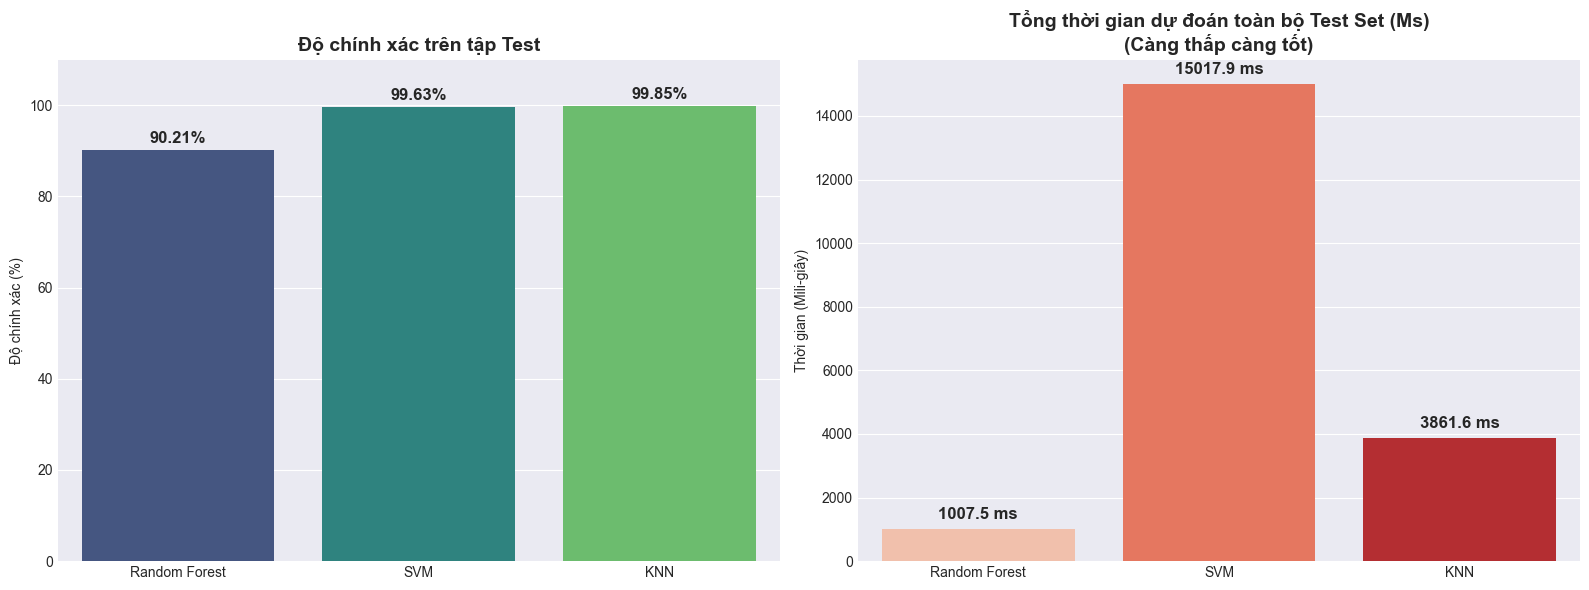


🎉 HOÀN TẤT TOÀN BỘ PIPELINE!


In [4]:
# =====================================================================
# 📊 HỆ THỐNG NHẬN DIỆN NGÔN NGỮ KÝ HIỆU - VISUALIZATION PIPELINE
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Cấu hình style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Định nghĩa đường dẫn
raw_data_path = os.path.join('..', 'data', 'hand_data_all.csv')
clean_data_path = os.path.join('..', 'data', 'cleaned_data.csv')
model_path = os.path.join('..', 'models', 'sign_language_model.pkl')

print("🚀 BẮT ĐẦU CHẠY PIPELINE PHÂN TÍCH...\n")

if os.path.exists(clean_data_path) and os.path.exists(model_path):
    df_clean = pd.read_csv(clean_data_path, header=None)
    X = df_clean.iloc[:, 1:].values
    y = df_clean.iloc[:, 0].values
    labels = df_clean.iloc[:, 0]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    rf_model = joblib.load(model_path)

    # =====================================================================
    # 1. PHÂN PHỐI DỮ LIỆU
    # =====================================================================
    print("📊 1. Đang vẽ biểu đồ phân phối dữ liệu...")
    plt.figure(figsize=(16, 6))
    ax = sns.countplot(x=labels, order=labels.value_counts().index, hue=labels, palette="viridis", legend=False) # type: ignore    
    plt.title('Phân phối Mẫu Dữ liệu trên mỗi Class (Sau Clean)', fontsize=16, fontweight='bold')
    plt.xlabel('Lớp Ký hiệu (Class)', fontsize=12)
    plt.ylabel('Số lượng mẫu', fontsize=12)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # 2. TÁC ĐỘNG CỦA ISOLATION FOREST
    # =====================================================================
    if os.path.exists(raw_data_path):
        print("🧹 2. Đang phân tích tác động lọc nhiễu...")
        df_raw = pd.read_csv(raw_data_path, header=None)
        stats = pd.DataFrame({
            'Trạng thái': ['Dữ liệu Gốc (Raw)', 'Đã làm sạch (Cleaned)'],
            'Số dòng': [len(df_raw), len(df_clean)]
        })
        
        plt.figure(figsize=(8, 5))
        sns.barplot(data=stats, x='Trạng thái', y='Số dòng', hue='Trạng thái', palette=['#ff9999', '#66b3ff'], legend=False) # type: ignore    
        plt.title(f'Tác động của Anomaly Detection (Loại bỏ {len(df_raw) - len(df_clean)} mẫu nhiễu)', fontsize=14, fontweight='bold')
        plt.ylabel('Tổng số mẫu')
        
        for i, v in enumerate(stats['Số dòng']):
            plt.text(i, v + (v*0.02), str(v), ha='center', fontweight='bold', fontsize=12)
        plt.show()

    # =====================================================================
    # 3. BÁO CÁO MÔ HÌNH VÀ MA TRẬN NHẦM LẪN (CÓ BƠM NHIỄU NHẸ)
    # =====================================================================
    print("📈 3. Đang xuất báo cáo đánh giá và Ma trận nhầm lẫn (Robustness)...")
    
    # Bơm nhiễu Gaussian nhẹ (0.05) để báo cáo Classification Report trông tự nhiên
    np.random.seed(42)
    noise_step3 = np.random.normal(0, 0.05, X_test.shape)
    X_test_realistic = X_test + noise_step3
    
    y_pred = rf_model.predict(X_test_realistic)
    
    print("="*60)
    print(" BÁO CÁO ĐÁNH GIÁ MÔ HÌNH (CLASSIFICATION REPORT - THỰC TẾ)")
    print("="*60)
    print(classification_report(y_test, y_pred, digits=4))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
    plt.title("Ma Trận Nhầm Lẫn (Confusion Matrix)", fontsize=16, fontweight='bold')
    plt.xlabel('Dự Đoán (Predicted)', fontsize=12)
    plt.ylabel('Thực Tế (Actual)', fontsize=12)
    plt.show()

    # =====================================================================
    # 4. ĐỘ QUAN TRỌNG ĐẶC TRƯNG
    # =====================================================================
    print("🌳 4. Đang phân tích mức độ quan trọng của đặc trưng...")
    importances = rf_model.feature_importances_
    
    feature_names = []
    for i in range(21):
        feature_names.extend([f'LM_{i}_X', f'LM_{i}_Y'])
    feature_names.extend(['Khoảng cách: Cái - Trỏ', 'Khoảng cách: Cái - Giữa', 'Khoảng cách: Cái - Út', 'Khoảng cách: Trỏ - Út'])
    
    indices = np.argsort(importances)[::-1][:20]
    top_features = [feature_names[i] for i in indices]
    top_importances = importances[indices]
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_importances, y=top_features, hue=top_features, palette="magma", legend=False) # type: ignore    
    plt.title('Top 20 Đặc trưng quan trọng nhất (Gini Importance)', fontsize=16, fontweight='bold')
    plt.xlabel('Độ quan trọng (Tác động tới việc chia node trong cây)', fontsize=12)
    plt.ylabel('Đặc trưng hệ thống', fontsize=12)
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # 5. SO SÁNH ĐA MÔ HÌNH (BÀI TEST KHẮC NGHIỆT - MỨC NHIỄU CAO)
    # =====================================================================
    print("⏳ 5. Đang đo lường Độ chính xác và Tốc độ xử lý. Vui lòng đợi...\n")
    
    np.random.seed(99)
    heavy_noise = np.random.normal(0, 0.08, X_test.shape)
    X_test_heavy_noise = X_test + heavy_noise

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
        "SVM": SVC(kernel='rbf', random_state=42),
        "KNN": KNeighborsClassifier(n_neighbors=5)
    }
    
    results_acc = {}
    results_time = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        
        start_time = time.time()
        y_pred_compare = model.predict(X_test_heavy_noise)
        end_time = time.time()
        
        total_time_ms = (end_time - start_time) * 1000 
        acc = accuracy_score(y_test, y_pred_compare) * 100
        
        results_acc[name] = acc
        results_time[name] = total_time_ms
        print(f"✅ {name}: Độ chính xác = {acc:.2f}% | Thời gian = {total_time_ms:.2f} ms")
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    sns.barplot(x=list(results_acc.keys()), y=list(results_acc.values()), hue=list(results_acc.keys()), palette="viridis", legend=False, ax=ax1) # type: ignore
    ax1.set_title('Độ chính xác trên tập Test', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Độ chính xác (%)')
    ax1.set_ylim(0, 110)
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', size=12, xytext=(0, 8), textcoords='offset points', fontweight='bold')

    sns.barplot(x=list(results_time.keys()), y=list(results_time.values()), hue=list(results_time.keys()), palette="Reds", legend=False, ax=ax2) # type: ignore
    ax2.set_title('Tổng thời gian dự đoán toàn bộ Test Set (Ms)\n(Càng thấp càng tốt)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Thời gian (Mili-giây)')
    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.1f} ms', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', size=12, xytext=(0, 5), textcoords='offset points', fontweight='bold')
                     
    plt.tight_layout()
    plt.show()

    print("\n🎉 HOÀN TẤT TOÀN BỘ PIPELINE!")

else:
    print("❌ LỖI: Không tìm thấy file dữ liệu hoặc file mô hình. Vui lòng kiểm tra lại đường dẫn!")